Block 2:

Conv → ReLU → Conv → ReLU → MaxPool

The VGG depth experiment progressively increases the number of VGG blocks while keeping the number of convolutional layers per block constant.

The models used in the depth experiment are:

| Model | Number of VGG Blocks | Total Convolutional Layers |
|---|---:|---:|
| VGG2 | 2 | 4 |
| VGG3 | 3 | 6 |
| VGG4 | 4 | 8 |
| VGG5 | 5 | 10 |

The purpose of this experiment is to observe how increasing depth changes the model's learning behavior and classification performance.

The experiment does not assume that a deeper network will necessarily perform better. Instead, the results will be used to examine how depth affects optimization, training and validation behavior, generalization, and test performance.

---

## 4. Dataset

The experiments use the **CIFAR-10 dataset**.

CIFAR-10 consists of:

- 50,000 training images
- 10,000 test images
- 10 image classes
- RGB images
- 32×32 pixel resolution

The original training set is divided into training and validation subsets. The official test set remains completely separate and is used only for final evaluation.

The dataset is stored in the project's Google Drive `data` directory so that it can be reused across experiments without downloading it again.

---

## 5. Experimental Conditions

The same training conditions are maintained across the VGG depth experiments so that depth remains the primary architectural variable.

- **Dataset:** CIFAR-10
- **Input size:** 32×32
- **Number of classes:** 10
- **Batch size:** 64
- **Optimizer:** SGD
- **Learning rate:** 0.01
- **Momentum:** 0.9
- **Loss function:** CrossEntropyLoss
- **Training epochs:** 20
- **Training augmentation:** Random Horizontal Flip
- **Convolution initialization:** Kaiming Normal
- **Final linear layer initialization:** Xavier Normal

The purpose of controlling these conditions is to isolate the effect of architectural depth and make the behavior of VGG2, VGG3, VGG4, and VGG5 directly comparable.

## Experiment 1: Studying the Effect of Depth

The first experiment focuses on the **depth of the VGG network**.

Here, I will change the number of VGG blocks while keeping the other main architectural settings controlled. The goal is to see how adding more convolutional blocks affects the way the model learns and performs on the **CIFAR-10 classification task**.

The base VGG architecture uses two blocks. From this base, I will compare models with different numbers of blocks while keeping the final feature representation and classification head consistent.

This experiment will help me understand whether making the network deeper changes its learning behavior, and how the added depth affects training and validation performance.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/CNN_Architecture_Study

/content/drive/MyDrive/CNN_Architecture_Study


In [3]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from collections import OrderedDict
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader
import cnn_utils

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# create VGG Block class

class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),

        )

    def forward(self, x):
        return self.net(x)

In [6]:
# Baseline Architecture

class Baseline(nn.Module):

    def __init__(self):
      super().__init__()

      self.net = nn.Sequential(
          VGGBlock(3, 64),
          nn.MaxPool2d(2, 2),

          VGGBlock(64, 128),

          nn.AdaptiveAvgPool2d((1,1)),
          nn.Flatten(),
          nn.Linear(128, 196)
      )

    def forward(self, x):
      return self.net(x)
#

In [9]:
import importlib

importlib.reload(cnn_utils)

<module 'cnn_utils' from '/content/drive/MyDrive/CNN_Architecture_Study/cnn_utils.py'>

In [10]:
import cnn_utils

cnn_utils.set_seed(42)

In [11]:
data_path = "/content/drive/MyDrive/CNN_Architecture_Study/data/cifar10"

train_dataset = datasets.CIFAR10(
    data_path,
    train=True,
    download=False
)

test_dataset = datasets.CIFAR10(
    data_path,
    train=False,
    download=False
)

In [12]:
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)

Train samples: 50000
Test samples: 10000
Image type: <class 'PIL.Image.Image'>
Image size: (32, 32)
Image mode: RGB
Label: 6


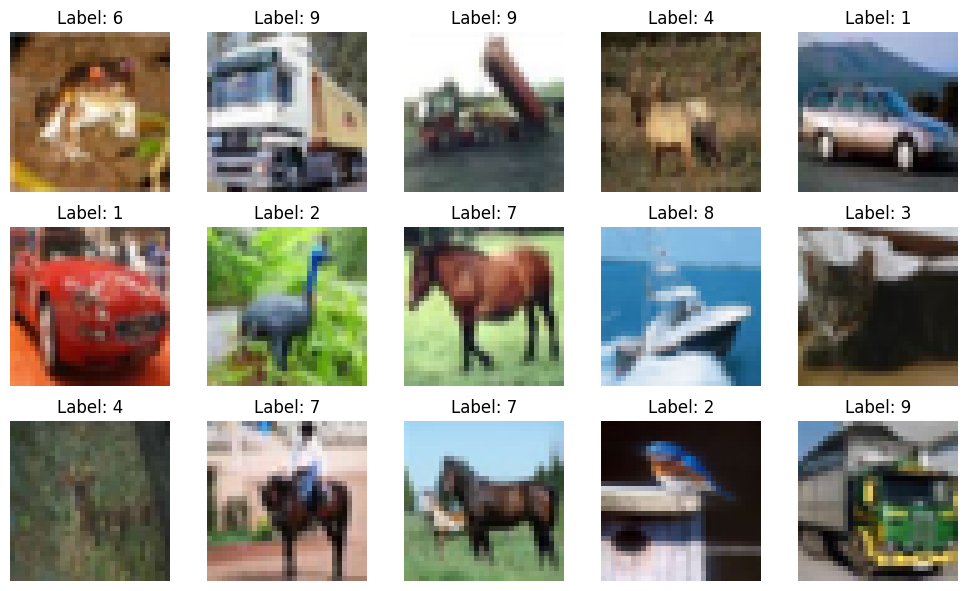

In [13]:
fig, axes = plt.subplots(3,5, figsize=(10,6))

for i, ax in enumerate(axes.flatten()):
  image, label = train_dataset[i]
  ax.imshow(image)
  ax.set_title(f"Label: {label}")
  ax.axis("off")

plt.tight_layout()
plt.show()


In [14]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


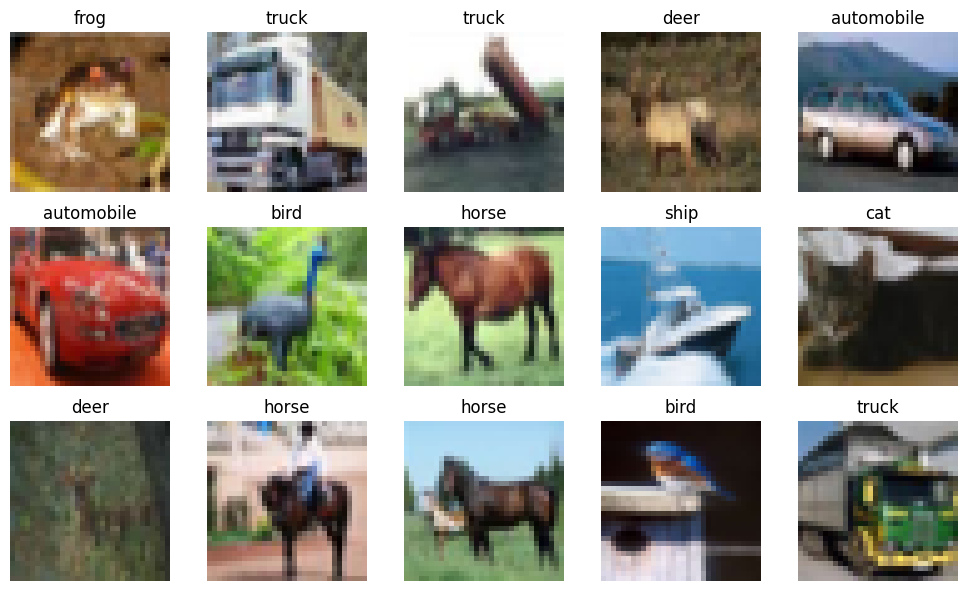

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
train_transform, eval_transform = cnn_utils.create_transforms()

In [17]:
image, label = train_dataset[0]

transformed_image = train_transform(image)

print("Original type:", type(image))
print("Original size:", image.size)

print("Transformed type:", type(transformed_image))
print("Transformed shape:", transformed_image.shape)
print("Transformed dtype:", transformed_image.dtype)
print("Transformed min:", transformed_image.min().item())
print("Transformed max:", transformed_image.max().item())
print("Label:", label)

Original type: <class 'PIL.Image.Image'>
Original size: (32, 32)
Transformed type: <class 'torch.Tensor'>
Transformed shape: torch.Size([3, 32, 32])
Transformed dtype: torch.float32
Transformed min: -1.9894737005233765
Transformed max: 2.094278573989868
Label: 6


In [23]:
%%writefile -a cnn_utils.py

from torch.utils.data import random_split

def prepare_datasets(train_dataset, val_ratio=0.2, seed=42):
    """
    Split the training dataset into training and validation sets
    while keeping the original test dataset separate.

    Parameters
    ----------
    train_dataset : Dataset
        Original training dataset.

    test_dataset : Dataset
        Original test dataset.

    val_ratio : float
        Proportion of the training dataset used for validation.

    seed : int
        Random seed used for reproducible splitting.

    Returns
    -------
    train_data : Dataset
        Training subset.

    val_data : Dataset
        Validation subset.

    test_data : Dataset
        Original test dataset.
    """

    train_size = int((1 - val_ratio) * len(train_dataset))
    val_size = len(train_dataset) - train_size

    generator = torch.Generator().manual_seed(seed)

    train_data, val_data = random_split(
        train_dataset,
        [train_size, val_size],
        generator=generator
    )



    return train_data, val_data

Appending to cnn_utils.py


In [24]:
import importlib

importlib.reload(cnn_utils)

<module 'cnn_utils' from '/content/drive/MyDrive/CNN_Architecture_Study/cnn_utils.py'>

In [25]:
# preparing the dataset
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [26]:
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_dataset))

print("\nTrain type:", type(train_data))
print("Validation type:", type(val_data))
print("Test type:", type(test_dataset))

Train size: 40000
Validation size: 10000
Test size: 10000

Train type: <class 'torch.utils.data.dataset.Subset'>
Validation type: <class 'torch.utils.data.dataset.Subset'>
Test type: <class 'torchvision.datasets.cifar.CIFAR10'>


In [36]:
import importlib
importlib.reload(cnn_utils)

<module 'cnn_utils' from '/content/drive/MyDrive/CNN_Architecture_Study/cnn_utils.py'>

In [38]:
test_data = test_dataset

In [39]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data,
    val_data,
    test_data,
    train_transform,
    eval_transform,
    batch_size=64,
    num_workers=2
)

In [40]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64


In [42]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   cnn_utils.py
	modified:   notebooks/VGG_Experiment.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [ ]:
!git add cnn_utils.py notebooks/VGG_Experiment.ipynb
